# Amortized Bayeian Workflow for Multifractal Models of Asset Returns

In [4]:
from datetime import datetime
from pathlib import Path

import bayesflow as bf
import keras

from mmar import statistics as stats, viz
from mmar.data import load_market_returns

from mmar import univariate as model, decisions
from mmar.viz import univariate as plots

TICKERS = ("SPMO", "VOO")
FIGURES_DIR = Path("figures/univariate")
CHECKPOINT_DIR = Path("checkpoints/univariate") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")

viz.configure_plot_style()

## 1. Model specification

$$r_t = \mu + \bar\sigma\sqrt{\theta_t(q)}\,z_t,
\qquad z_t\sim t_\nu\sqrt{(\nu-2)/\nu}.$$

Four fixed parameters; eight 32-day volatility blocks with random circular phase.
Shocks are independent conditional on the cascade, but returns are not marginally IID.
Whole paths crossing −100% are redrawn; shocks are never empirically centered or rescaled.

In [5]:
model.prior_table(model.PRIOR)

,prior,meaning
parameter,,
mu,"Normal(0, 0.0015²)",Daily drift
sigma_bar,"Uniform(0.005, 0.025)",RMS scale before path rejection
q,"Uniform(0.52, 0.9)",Cascade asymmetry
nu,"2 + exp(Uniform(log(0.05), log(10)))",Student-t degrees of freedom


In [6]:
observed_returns = load_market_returns(TICKERS)
observed_window = observed_returns.tail(model.WINDOW)

## 2. Prior predictive checks

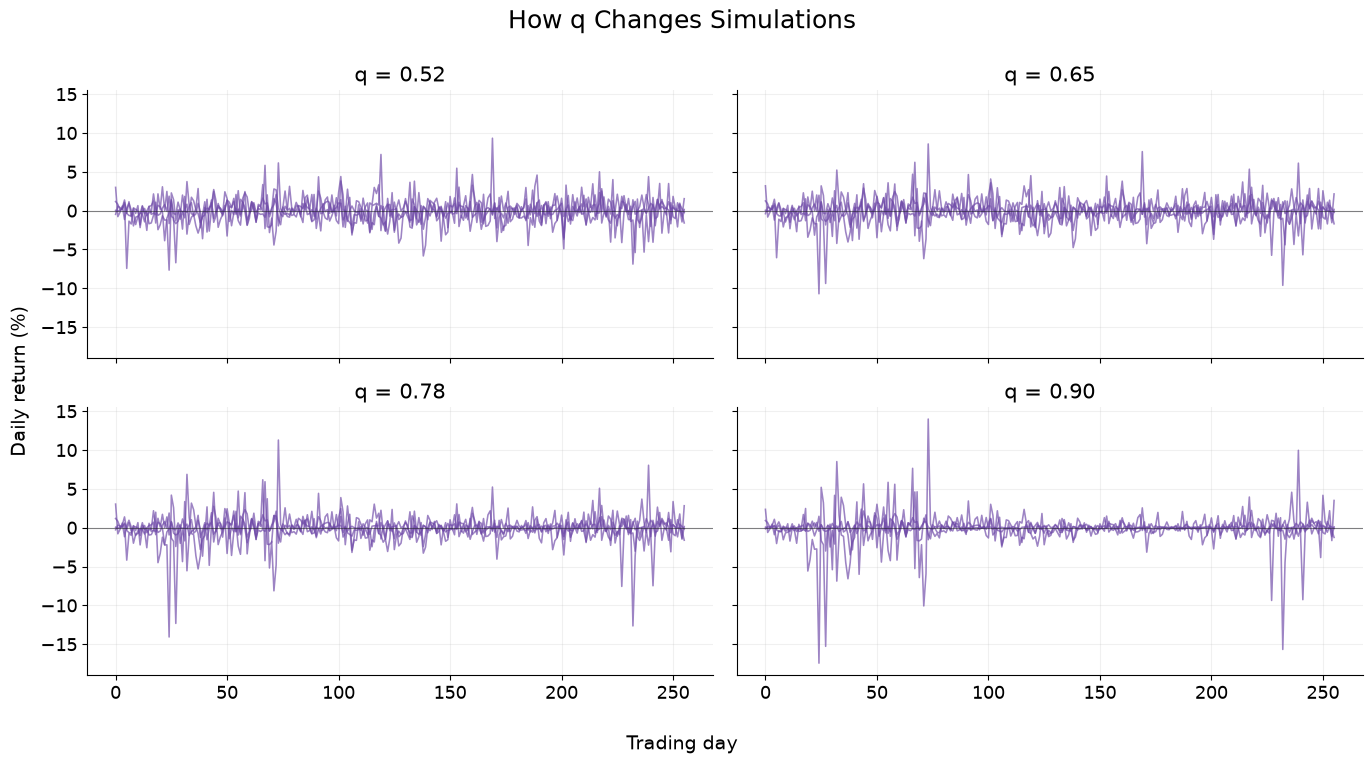

In [8]:
prior_data = model.simulate(3_000, seed=42, prior=model.PRIOR)
prior_returns = prior_data["returns"]

fig = plots.plot_q_turbulence(model.q_scenarios((0.52, 0.65, 0.78, 0.90), seed=42))
_ = viz.save_figure(fig, "01_prior_q_turbulence.png", FIGURES_DIR)

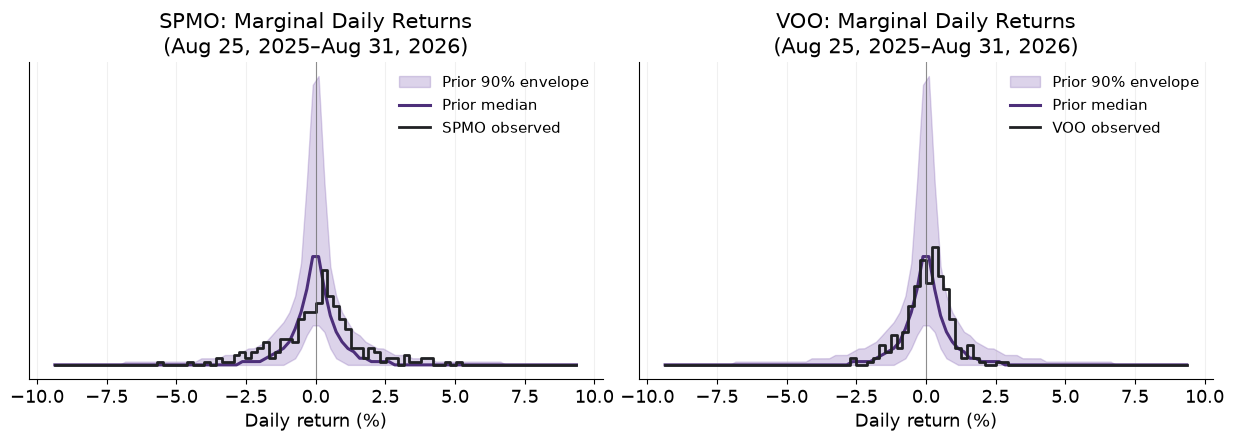

In [9]:
fig = plots.plot_marginal_return_histograms(100 * prior_returns, 100 * observed_window, tickers=TICKERS)
_ = viz.save_figure(fig, "02_prior_marginal_returns.png", FIGURES_DIR)

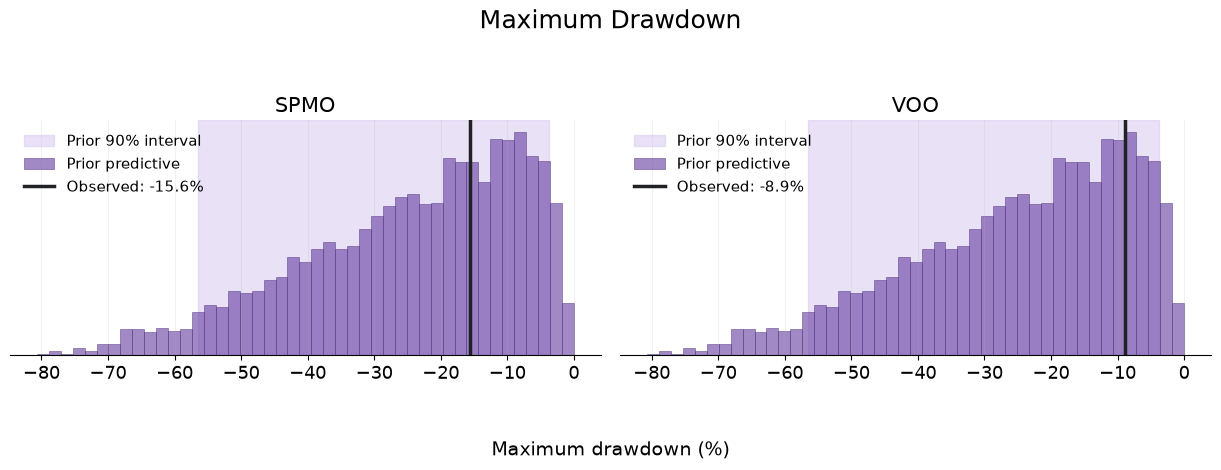

In [10]:
prior_stats = stats.statistics(prior_returns)
observed_stats = stats.statistics(observed_window.to_numpy().T)
observed_stats.index = TICKERS

fig = plots.plot_max_drawdown_checks(prior_stats, observed_stats, tickers=TICKERS)
_ = viz.save_figure(fig, "03_prior_max_drawdown.png", FIGURES_DIR)

In [11]:
envelope = stats.pushforward_envelope_table(prior_stats, observed_stats).rename(
    columns={"observed_pct": "observed", "prior_q05_pct": "prior_q05", "prior_q95_pct": "prior_q95"})
envelope.style.format(precision=2)

,ticker,stat,observed,prior_q05,prior_q95,inside_prior_90pct_band
0,SPMO,mean_pct,0.11,-0.29,0.28,True
1,SPMO,volatility_pct,1.52,0.41,2.40,True
2,SPMO,avg_abs_return_pct,1.10,0.27,1.53,True
3,SPMO,q01_pct,-3.63,-6.66,-0.97,True
4,SPMO,q05_pct,-2.60,-3.40,-0.43,True
5,SPMO,q95_pct,2.72,0.44,3.41,True
6,SPMO,q99_pct,4.02,1.03,6.59,True
7,SPMO,es05_pct,-3.35,-5.58,-0.88,True
8,SPMO,max_drawdown_pct,-15.64,-56.48,-3.71,True
9,SPMO,terminal_wealth,1.27,0.46,2.03,True


## 3. Amortized inference

Constraints are inverted by the adapter: all posterior draws are in original units.
$\mu$ stays unbounded. Normalized returns retain their observed location and scale as conditions.

In [ ]:
adapter = (
    bf.Adapter()
    .constrain("sigma_bar", lower=model.PRIOR.sigma_low, upper=model.PRIOR.sigma_high)
    .constrain("q", lower=model.PRIOR.q_low, upper=model.PRIOR.q_high)
    .constrain("nu", lower=model.PRIOR.nu_low, upper=model.PRIOR.nu_high)
    .concatenate(model.PARAMETER_NAMES, into="inference_variables")
    .rename("series", "summary_variables")
    .rename("context", "inference_conditions")
)

inference_network = bf.networks.CouplingFlow(
    transform="spline", 
    depth=4, 
    subnet_kwargs={"widths": (64, 64)}
)

summary_network = bf.networks.FusionTransformer()

workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=summary_network,
    inference_network=inference_network,
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, clipnorm=5),
    standardize=("inference_variables", "inference_conditions"),
    checkpoint_filepath=CHECKPOINT_DIR,
    checkpoint_name="best",
    save_best_only=True
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.


In [27]:
training_data = model.training_data(100_000, prior=model.PRIOR)
validation_data = model.training_data(500, prior=model.PRIOR)

In [28]:
history = workflow.fit_offline(
    data=training_data, 
    validation_data=validation_data, 
    epochs=50, 
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - loss: 5.0714 - val_loss: 5.0193
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 4.8105 - val_loss: 4.5663
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - loss: 4.3647 - val_loss: 4.2912
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 4.2203 - val_loss: 4.2156
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - loss: 4.1526 - val_loss: 4.0739
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 4.1176 - val_loss: 4.1474
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 4.0850 - val_loss: 4.0178
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 4.0427 - val_loss: 4.0022
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 4.0311 - val_loss: 3.9946
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 4.0117 - val_loss: 3.9771
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 3.9934 - val_loss: 4.0111
Epoch 12

KeyboardInterrupt: 

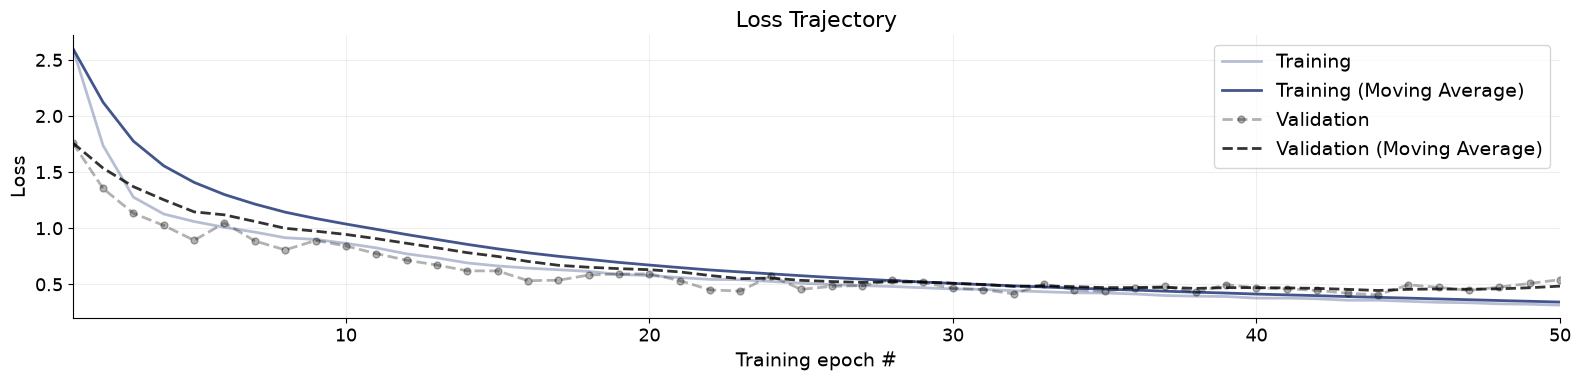

In [ ]:
fig = bf.diagnostics.loss(history)
_ = viz.save_figure(fig, "04_training_loss.png", FIGURES_DIR)

## 4. Parameter recovery and calibration

In [21]:
test_data = model.simulate(300, prior=model.PRIOR)
validation_samples = model.sample_posterior(workflow, test_data["returns"], num_samples=1000)

Summarizing:   0%|          | 0/5 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/5 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 8.41 seconds.


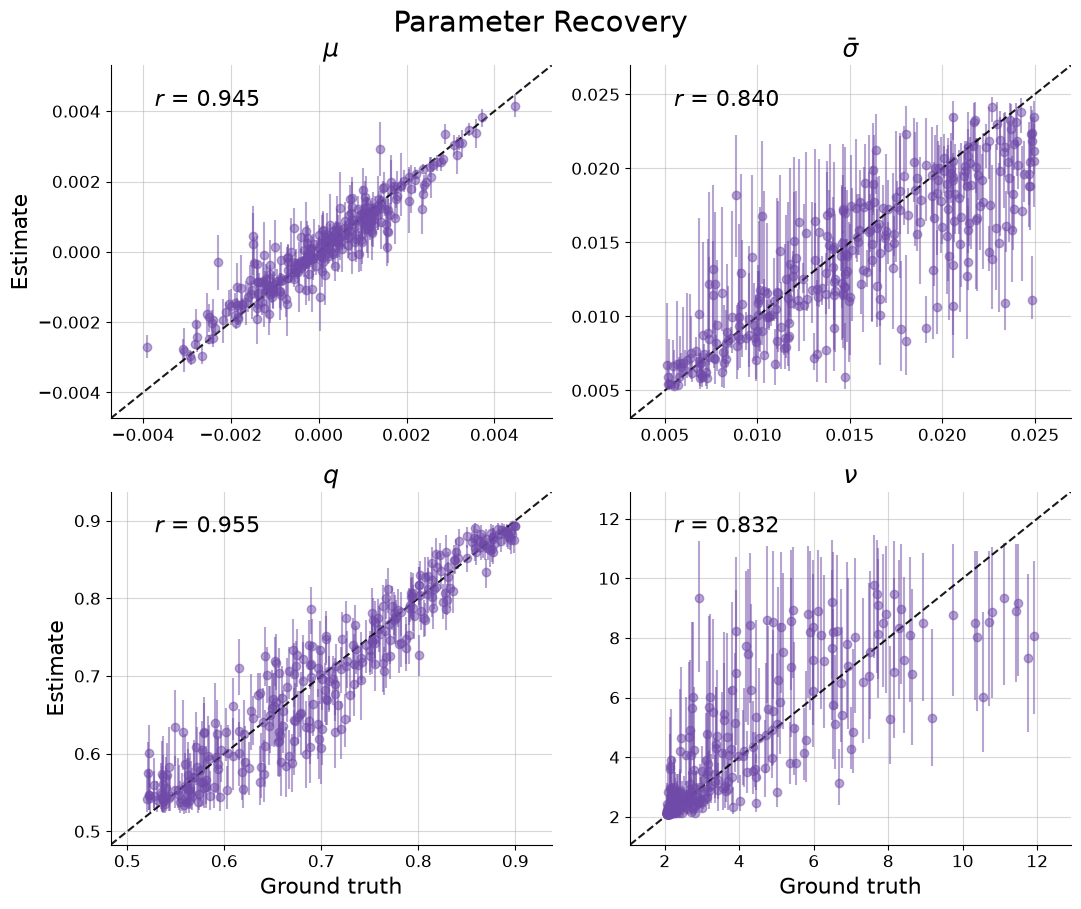

In [22]:
fig = viz.plot_recovery(validation_samples, test_data["theta"], model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "05_parameter_recovery.png", FIGURES_DIR)

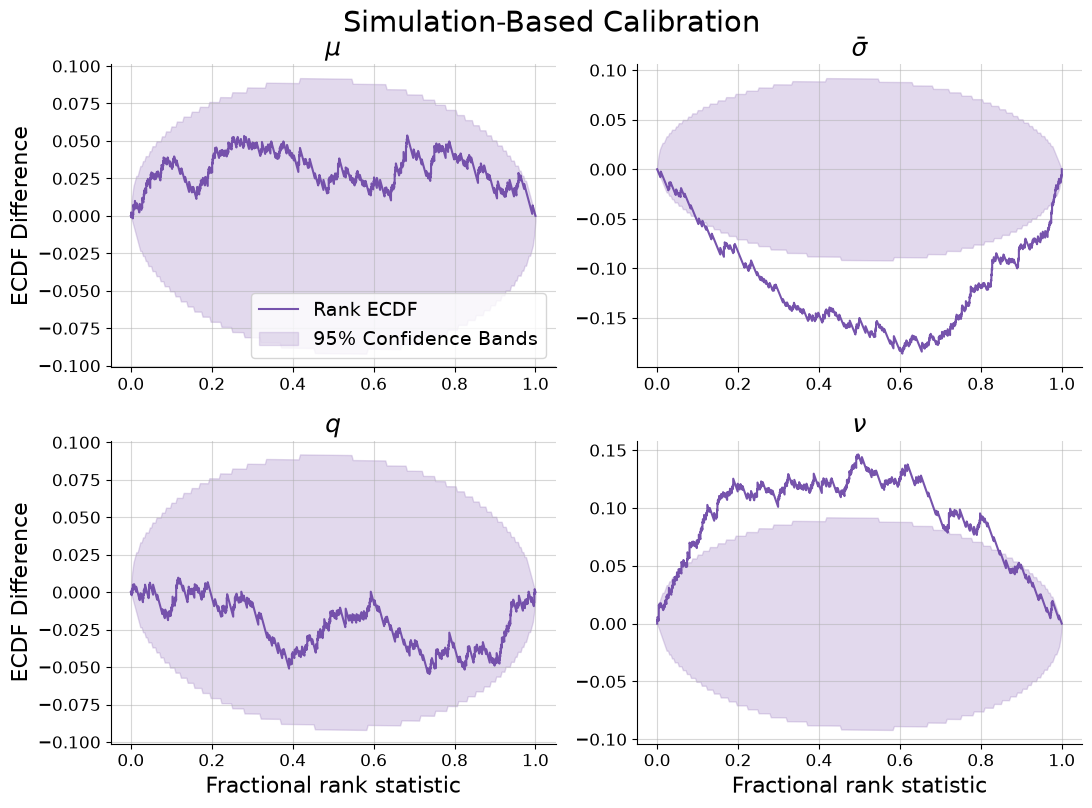

In [23]:
fig = viz.plot_calibration(validation_samples, test_data["theta"], model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "06_simulation_based_calibration.png", FIGURES_DIR)

## 5. Posterior predictive checks

Fresh 256-day resimulations: 68% and 92% intervals, observed returns, wealth and marginal histograms.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 7.07 seconds.


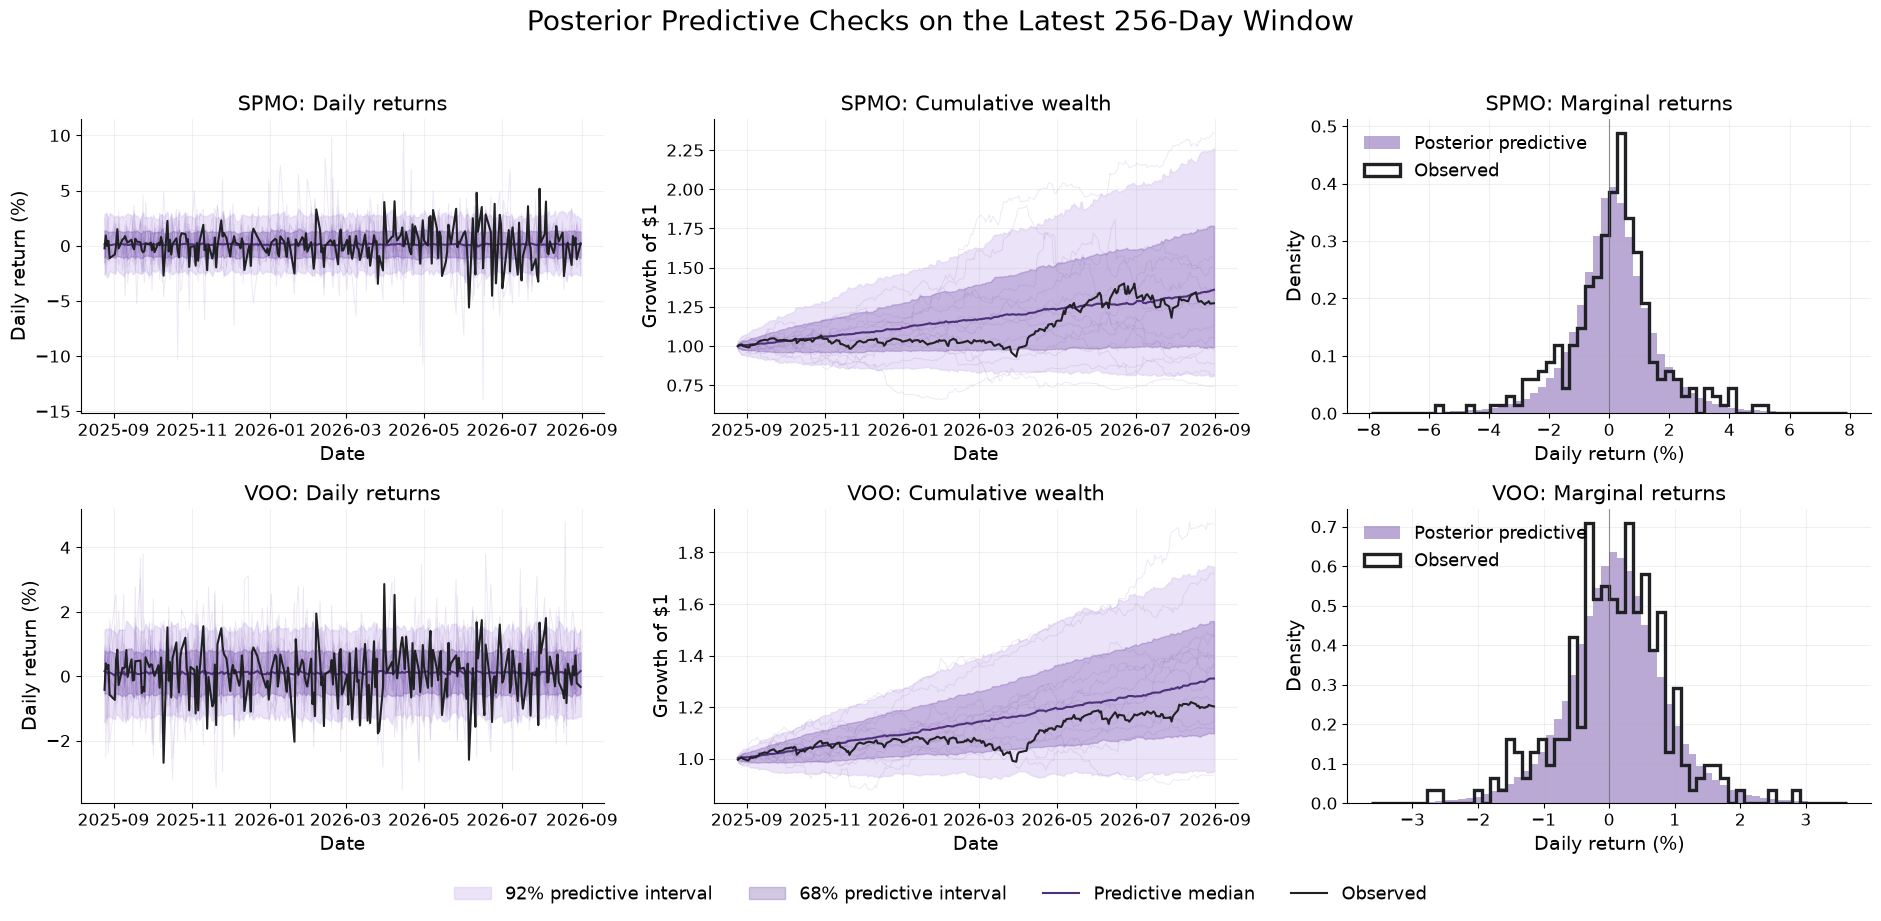

In [24]:
observed_windows = observed_window.to_numpy(dtype="float32").T
observed_posterior = model.sample_posterior(workflow, observed_windows, 600)
posterior_paths = model.posterior_resimulations(observed_posterior)

fig = plots.plot_posterior_predictive_checks(
    posterior_paths, observed_windows, [observed_window.index] * 2, tickers=TICKERS,
)

_ = viz.save_figure(fig, "07_posterior_predictive_checks.png", FIGURES_DIR)

## 6. Amortized decisions

20-day VaR and ES versus trailing historical simulation. Bands show variation across posterior
parameters plus simulation noise. Fresh cascades are scenarios, not a filtered continuation of today's volatility.

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 10.60 seconds.


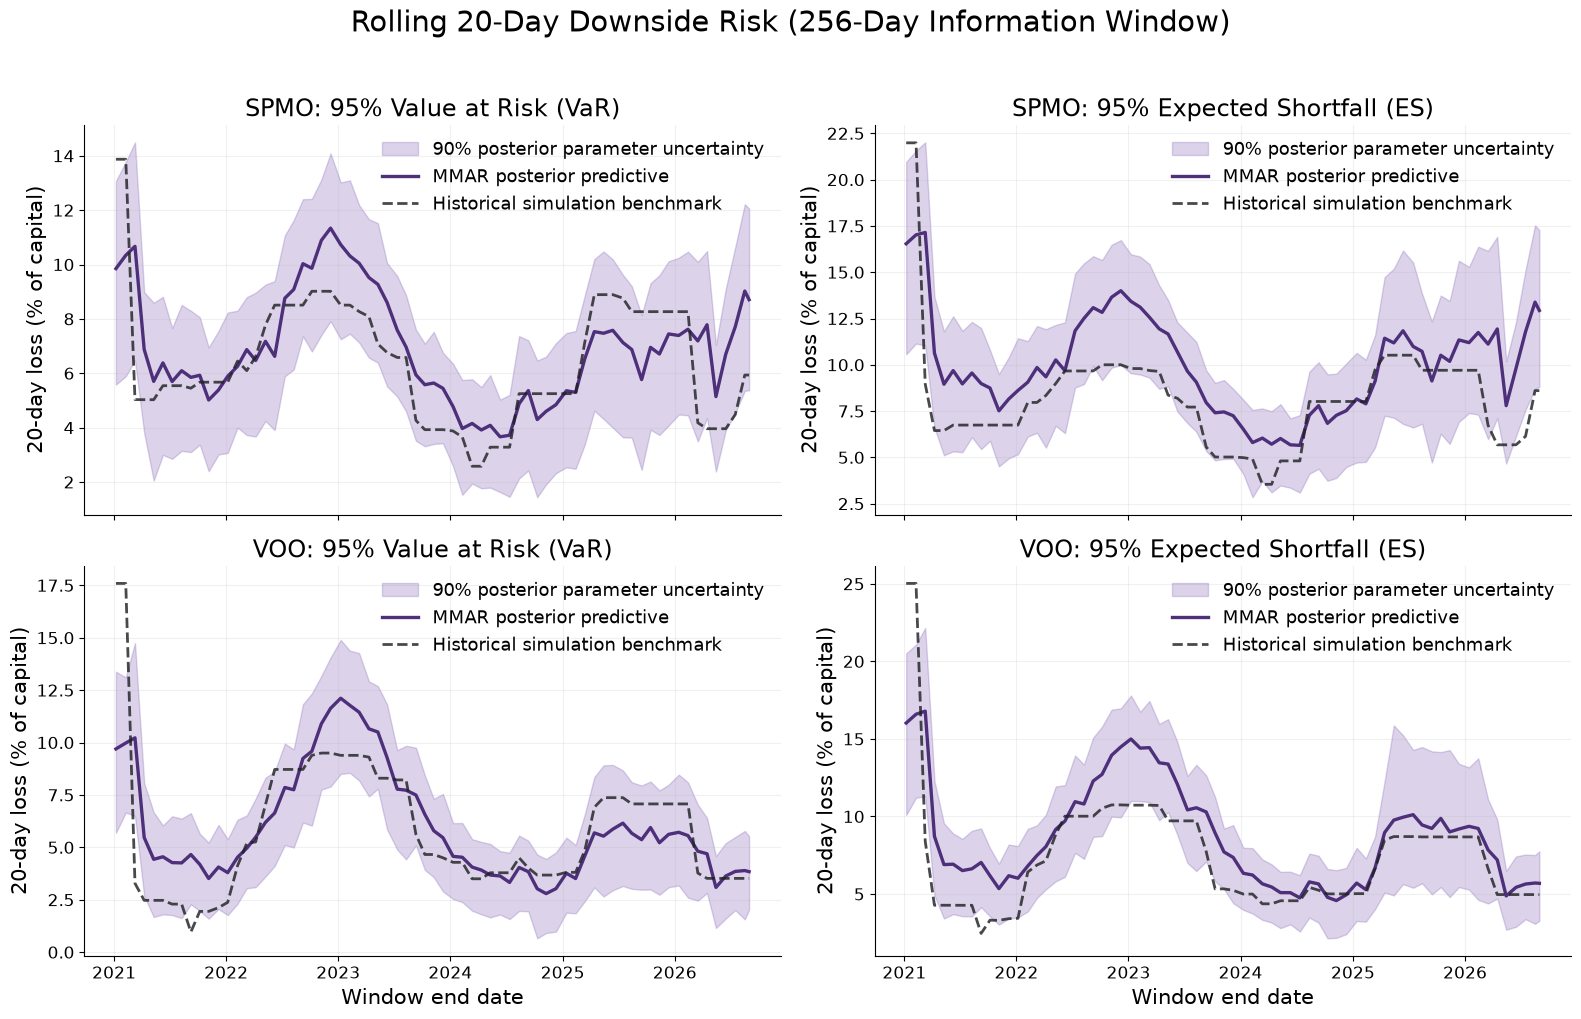

In [25]:
rolling_windows, rolling_metadata = decisions.rolling_return_windows(observed_returns, TICKERS, step=21)
rolling_posteriors = model.sample_posterior(workflow, rolling_windows, 500)

decision_table = decisions.posterior_decision_table(
    rolling_posteriors, rolling_metadata, observed_returns,
    horizon=20, n_parameter_draws=160, n_replications=192,
)

decision_table.to_csv(FIGURES_DIR / "rolling_decisions.csv", index=False)

fig = plots.plot_rolling_risk(decision_table, tickers=TICKERS)
_ = viz.save_figure(fig, "08_rolling_var_es.png", FIGURES_DIR)

## 7. Deep ensembles

To come.